In [1]:
!pip install gpytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 10.8 MB/s eta 0:00:00


In [57]:
import numpy as np
import torch
import gpytorch
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
dtype = torch.float64
torch.set_default_dtype(dtype)

Using device: cpu


In [58]:
#@title GT functions

def f1(x, A=1.0, tau=1.6, offset=0.05):
    """
    Monotonic increasing function with saturation.
    """
    return offset + A * (1.0 - np.exp(-x / tau))

def f2(x, L=1.0, x0=2.5, k=3.0, offset=0.05):
    """
    Sigmoid-like transition.
    """
    return offset + L / (1 + np.exp(-k * (x - x0)))

def f3(x, x0=2.5, gamma=0.25, A=1.0, offset=0.05):
    """
    Lorentzian resonance peak.
    """
    return offset + A * gamma**2 / ((x - x0)**2 + gamma**2)

def f4(x, A=1.0, gamma=0.35, w=4.0, offset=0.0):
    """
    Damped oscillatory response.
    """
    return offset + A * np.exp(-gamma * x) * np.cos(w * x)

In [59]:
#@title auxilary functions

def generate_experiment_data(f_true, x_grid, n_points=9, noise_std=0.05, seed=None, plot=True):
    """
    Generate sparse noisy experimental observations from a ground truth function.

    Parameters
    ----------
    f_true : function
        Ground truth function f(x)
    x_grid : array
        Dense grid of x values
    n_train : int
        Number of experimental points
    noise_std : float
        Standard deviation of Gaussian noise
    seed : int or None
        Random seed for reproducibility
    plot : bool
        Whether to visualize the data

    Returns
    -------
    x_train, y_train
    """

    if seed is not None:
        np.random.seed(seed)

    idx = np.sort(np.random.choice(np.arange(len(x_grid)), size=n_points, replace=False))
    x_train = x_grid[idx]
    y_train = f_true(x_train) + np.random.normal(0, noise_std, size=n_points)

    if plot:
        plt.figure(figsize=(7,4))
        plt.plot(x_grid, f_true(x_grid), label="True function")
        plt.scatter(x_train, y_train, color="red", s=60, label="Observed points", zorder=3)
        plt.xlabel("x")
        plt.ylabel("y")
        plt.legend()
        plt.show()

    return x_train, y_train

In [60]:
#@title GP model

class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

def train_gp(model, likelihood, train_x, train_y, lr=0.05, training_iter=200, plot=True):
    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    losses = []

    for i in range(training_iter):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    if plot:
        plt.figure(figsize=(6, 3))
        plt.plot(losses)
        plt.xlabel("Iteration")
        plt.ylabel("Negative log marginal likelihood")
        plt.title("Training loss")
        plt.show()

    return losses

# Hackathon Task

The objective is to explore an alternative workflow for interpreting sparse experimental data using Gaussian Processes (GP).


Instead of relying solely on the most probable GP prediction (i.e., the posterior mean), we consider the following approach:

1. Fit a GP model to a small set of noisy observations.
2. Draw multiple candidate functions from the GP posterior (Thompson-style sampling).
3. Treat these sampled functions as plausible hypotheses consistent with the data.
4. Select the final candidate based on external criteria such as known physics, constraints, or expected qualitative behavior.


In this notebook we implement the first three steps of this workflow.
The goal of the hackathon is to develop possible realizations of Step 4:
designing criteria or algorithms for ranking and selecting the most meaningful prediction from the GP posterior.


**Please, do not forget to submit your result. A short YouTube tutorial from Utkarsh explaining how to submit your results:**
https://www.youtube.com/watch?v=QcwQkAocrDY&t=35s

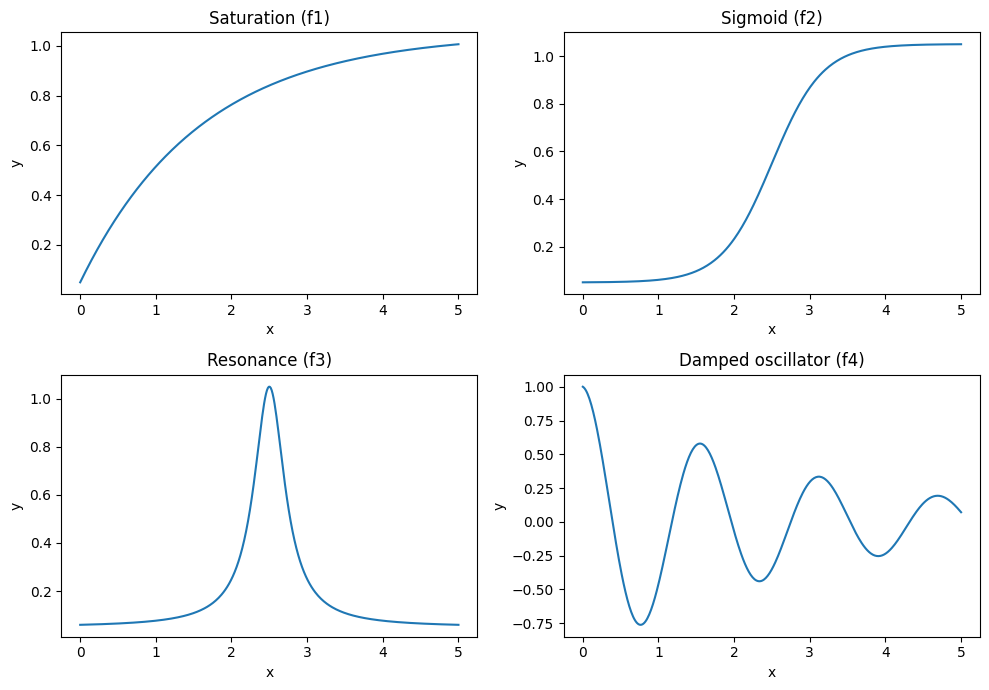

In [61]:
x_grid = np.linspace(0.0, 5.0, 400)
y1 = f1(x_grid)
y2 = f2(x_grid)
y3 = f3(x_grid)
y4 = f4(x_grid)

fig, ax = plt.subplots(2,2, figsize = (10,7))

for ax_ ,yy in zip(ax.flatten(), [y1, y2, y3, y4]):
  ax_.plot(x_grid, yy)
  ax_.set_xlabel("x")
  ax_.set_ylabel("y")

for ax_ ,ttl in zip(ax.flatten(), ['Saturation (f1)', 'Sigmoid (f2)', 'Resonance (f3)', 'Damped oscillator (f4)']):
  ax_.set_title(ttl)

plt.tight_layout()
# plt.show()

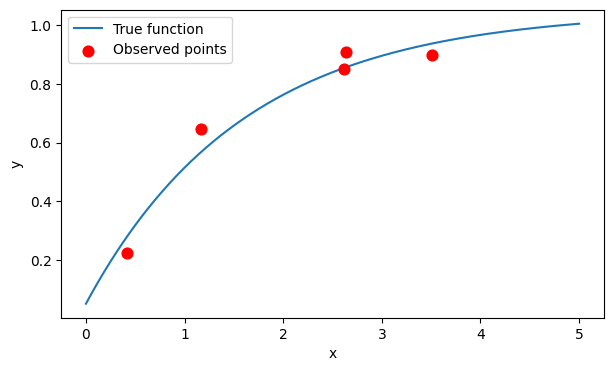

In [68]:
#choose function
f= f1

x_exp, y_exp = generate_experiment_data(f, x_grid, n_points=5, noise_std=0.1, seed=42)

#converting to torch.tensor
train_x = torch.tensor(x_exp, dtype=dtype, device=device).unsqueeze(-1)
train_y = torch.tensor(y_exp, dtype=dtype, device=device)

test_x = torch.tensor(x_grid, dtype=dtype, device=device).unsqueeze(-1)

In [69]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x, train_y, likelihood)

model = model.to(device=device, dtype=dtype)
likelihood = likelihood.to(device=device, dtype=dtype)



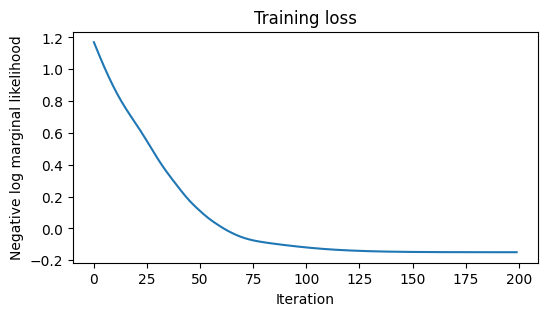

In [70]:
losses = train_gp(model, likelihood, train_x, train_y, lr=0.05, training_iter=200, plot=True)

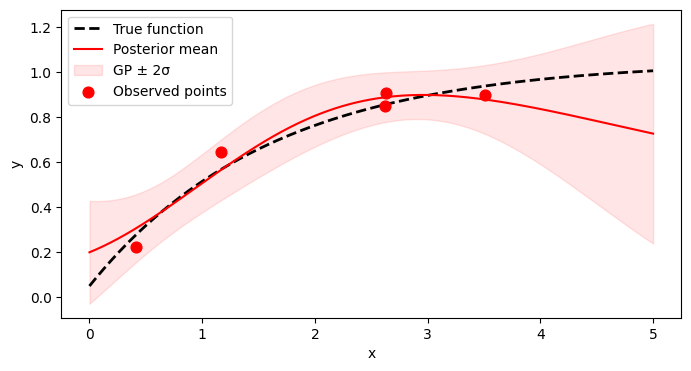

In [71]:
model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    posterior = model(test_x)
    pred_mean = posterior.mean.cpu().numpy()
    pred_std = posterior.stddev.cpu().numpy()

plt.figure(figsize=(8, 4))
plt.plot(x_grid, f(x_grid), 'k--', label="True function", linewidth=2)
plt.plot(x_grid, pred_mean, 'r',label="Posterior mean", linestyle="-")
plt.fill_between(
    x_grid,
    pred_mean - 2 * pred_std,
    pred_mean + 2 * pred_std,
    alpha=0.1,
    label="GP ± 2σ",
    color='r'
)
plt.scatter(x_exp, y_exp, color="red", s=60, label="Observed points", zorder=3)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [72]:
#Tompson sampling

n_candidates = 64 #number of the cundidate functions

with torch.no_grad():
    posterior = model(test_x)
    samples = posterior.sample(torch.Size([n_candidates]))

samples_np = samples.cpu().numpy() # - candidate function

/usr/local/lib/python3.12/dist-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


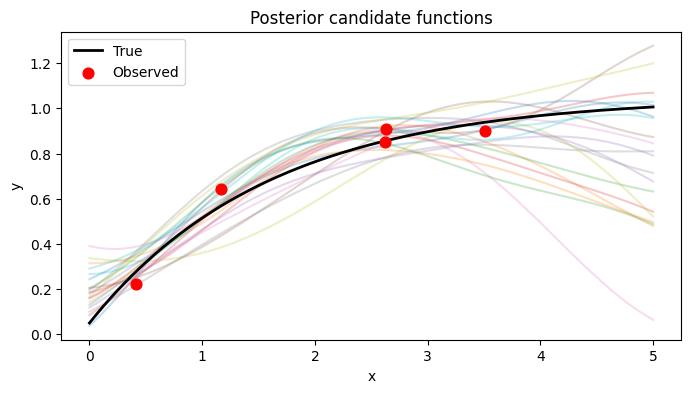

In [73]:
plt.figure(figsize=(8, 4))

for i in range(min(n_candidates, 20)):
    plt.plot(x_grid, samples_np[i], alpha=0.25)

plt.plot(x_grid, f(x_grid), color="black", linewidth=2, label="True")
plt.scatter(x_exp, y_exp, color="red", s=60, zorder=3, label="Observed")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Posterior candidate functions")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


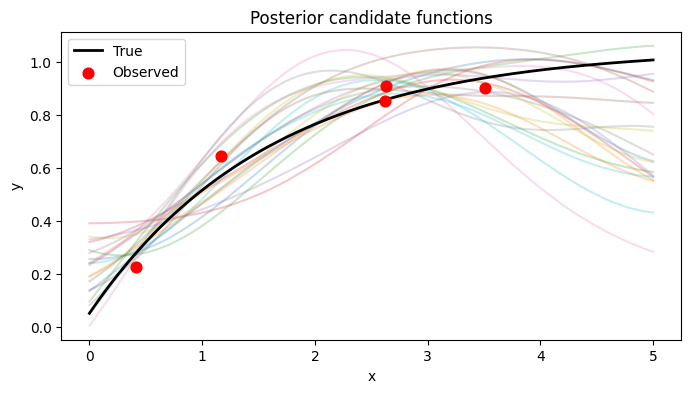

In [84]:
#Tompson sampling

n_candidates = 64 #number of the cundidate functions

with torch.no_grad():
    posterior = model(test_x)
    samples = posterior.sample(torch.Size([n_candidates]))

samples_np = samples.cpu().numpy() # - candidate function

plt.figure(figsize=(8, 4))

for i in range(min(n_candidates, 20)):
    plt.plot(x_grid, samples_np[i], alpha=0.25)

plt.plot(x_grid, f(x_grid), color="black", linewidth=2, label="True")
plt.scatter(x_exp, y_exp, color="red", s=60, zorder=3, label="Observed")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Posterior candidate functions")
plt.legend()
plt.show()

# Can we design criteria or algorithms for ranking and selecting the most meaningful candidate function?

In [13]:
# you code

# choose f4 because
Most physics-rich:

- Decay rate (γ) — energy dissipation
- Frequency (ω) — oscillation period
- Amplitude envelope — exponential, not arbitrary
- Phase — starts at a known value
- Zero crossings — predictable, countable

In [22]:
import numpy as np
import torch
import gpytorch
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema

torch.manual_seed(0)
np.random.seed(0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.float64
torch.set_default_dtype(dtype)

# ── Ground truth ──────────────────────────────────────────────────────────────

def f4(x, A=1.0, gamma=0.35, w=4.0, offset=0.0):
    """Damped oscillatory response."""
    return offset + A * np.exp(-gamma * x) * np.cos(w * x)






In [23]:
# ── GP model ──────────────────────────────────────────────────────────────────

class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

def train_gp(model, likelihood, train_x, train_y, lr=0.05, training_iter=200):
    model.train(); likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    for _ in range(training_iter):
        optimizer.zero_grad()
        loss = -mll(model(train_x), train_y)
        loss.backward()
        optimizer.step()

In [24]:
# ── Data & GP fit ─────────────────────────────────────────────────────────────

x_grid = np.linspace(0.0, 5.0, 400)
f = f4

np.random.seed(42)
idx = np.sort(np.random.choice(len(x_grid), size=5, replace=False))
x_exp = x_grid[idx]
y_exp = f(x_exp) + np.random.normal(0, 0.1, size=5)

train_x = torch.tensor(x_exp, dtype=dtype, device=device).unsqueeze(-1)
train_y = torch.tensor(y_exp, dtype=dtype, device=device)
test_x  = torch.tensor(x_grid, dtype=dtype, device=device).unsqueeze(-1)

likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device=device, dtype=dtype)
model      = ExactGPModel(train_x, train_y, likelihood).to(device=device, dtype=dtype)
train_gp(model, likelihood, train_x, train_y)

model.eval(); likelihood.eval()

with torch.no_grad():
    posterior = model(test_x)
    samples   = posterior.sample(torch.Size([64]))

samples_np = samples.cpu().numpy()   # shape: (64, 400)

/usr/local/lib/python3.12/dist-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


In [25]:
# So the natural constraints to impose are:

# Monotonic envelope — local maxima must decay
# Zero crossings — must be roughly periodic
# Sign at x=0 — f(0) should be positive (cosine starts at 1)
# Frequency consistency — spacing between peaks should be roughly constant
# Long-tail behavior — must decay toward 0, not diverge or saturate

In [26]:
# ═════════════════════════════════════════════════════════════════════════════
#  PHYSICS SCORING
#  Each criterion returns a penalty ≥ 0.  Lower total = more physical.
# ═════════════════════════════════════════════════════════════════════════════

def score_sign_at_origin(sample):
    """
    CONSTRAINT: f(0) > 0  (cosine starts at +1, A > 0)
    Penalty = magnitude of violation if f(0) ≤ 0, else 0.
    """
    return max(0.0, -sample[0])


def score_decaying_envelope(sample, x=x_grid, order=5):
    """
    CONSTRAINT: successive local maxima must decrease in amplitude.
    Penalty = sum of positive differences where a later max exceeds an earlier one.
    """
    maxima_idx = argrelextrema(sample, np.greater, order=order)[0]
    if len(maxima_idx) < 2:
        return 0.0   # can't evaluate — no penalty
    maxima_vals = sample[maxima_idx]
    violations  = np.maximum(0, np.diff(maxima_vals))   # later max > earlier max
    return float(violations.sum())


def score_zero_crossing_regularity(sample, x=x_grid):
    """
    CONSTRAINT: zero crossings should be roughly equally spaced (periodic ω).
    Penalty = std of intervals between zero crossings (normalised by mean interval).
    """
    signs    = np.sign(sample)
    crossings = np.where(np.diff(signs) != 0)[0]
    if len(crossings) < 3:
        return 1.0   # not enough oscillation — assign moderate penalty
    intervals = np.diff(crossings)
    return float(np.std(intervals) / (np.mean(intervals) + 1e-8))


def score_tail_decay(sample, x=x_grid, tail_frac=0.2):
    """
    CONSTRAINT: function must decay toward 0 at large x.
    Penalty = mean absolute value in the tail region.
    """
    tail_start = int(len(x) * (1 - tail_frac))
    return float(np.mean(np.abs(sample[tail_start:])))


def total_score(sample, weights=None):
    """
    Weighted sum of all physics penalties.
    weights = dict with keys: 'origin', 'envelope', 'crossing', 'tail'
    """
    if weights is None:
        weights = {'origin': 1.0, 'envelope': 1.0, 'crossing': 1.0, 'tail': 1.0}

    scores = {
        'origin'  : score_sign_at_origin(sample),
        'envelope': score_decaying_envelope(sample),
        'crossing': score_zero_crossing_regularity(sample),
        'tail'    : score_tail_decay(sample),
    }
    total = sum(weights[k] * v for k, v in scores.items())
    return total, scores


In [27]:
# ── Score all candidates ──────────────────────────────────────────────────────

all_scores = []
for s in samples_np:
    t, breakdown = total_score(s)
    all_scores.append(t)

all_scores   = np.array(all_scores)
ranked_idx   = np.argsort(all_scores)          # best first
best_idx     = ranked_idx[0]
worst_idx    = ranked_idx[-1]

print(f"Best  candidate index: {best_idx}  | score: {all_scores[best_idx]:.4f}")
print(f"Worst candidate index: {worst_idx} | score: {all_scores[worst_idx]:.4f}")

Best  candidate index: 53  | score: 1.0764
Worst candidate index: 48 | score: 1.2684


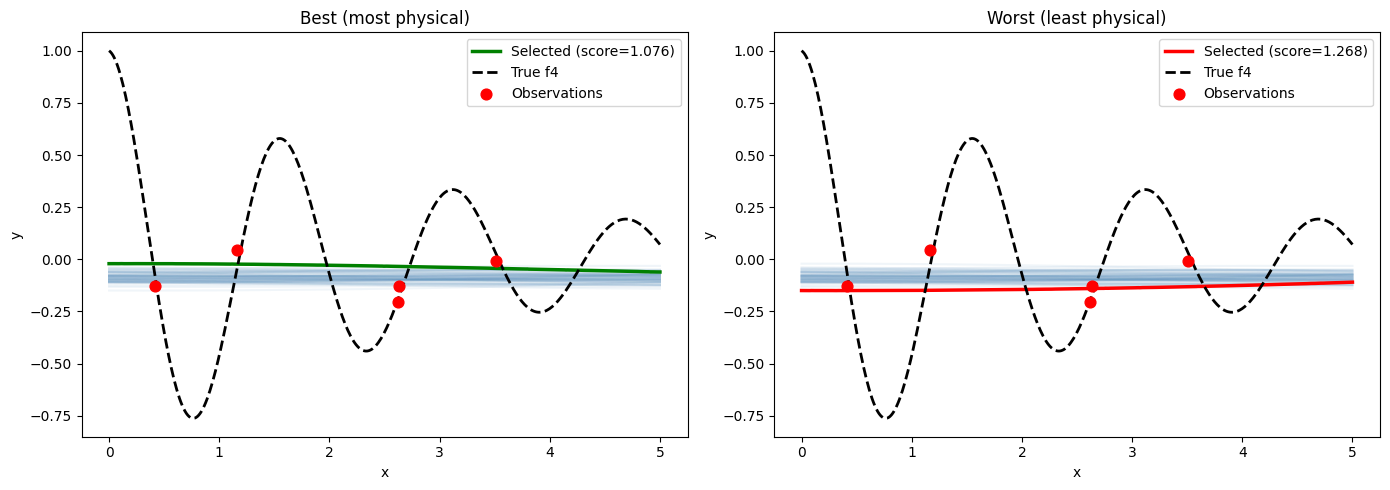

In [29]:
# ── Visualise ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, title, highlight_idx in zip(axes,
                                    ["Best (most physical)", "Worst (least physical)"],
                                    [best_idx, worst_idx]):
    # all candidates (faint)
    for i in range(len(samples_np)):
        ax.plot(x_grid, samples_np[i], color='steelblue', alpha=0.08)

    # highlighted candidate
    color = 'green' if highlight_idx == best_idx else 'red'
    ax.plot(x_grid, samples_np[highlight_idx], color=color, linewidth=2.5,
            label=f'Selected (score={all_scores[highlight_idx]:.3f})')

    # ground truth
    ax.plot(x_grid, f(x_grid), 'k--', linewidth=2, label='True f4')
    ax.scatter(x_exp, y_exp, color='red', s=60, zorder=5, label='Observations')

    ax.set_title(title)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.legend()

# plt.suptitle("Physics-Constrained Candidate Selection — Damped Oscillator", fontsize=13)
plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/physics_selection.png", dpi=150, bbox_inches='tight')
plt.show()




What's happening:

- With only 5 points, most of which are near y≈0, the GP collapses to a near-flat line
All 64 candidates are essentially flat — so the physics scoring is ranking nearly identical bad candidates
The score difference (1.076 vs 1.268) is tiny — confirms they're all similar

- Root cause: The RBF kernel with default lengthscale is way too long — it smooths over the oscillations entirely. The GP never "sees" the oscillatory structure.

- This is actually a great finding — it means we need to fix the GP before the scoring matters. Options:

    - More data points — give it 15-20 points so oscillations are visible
    - Better kernel — use a periodic × decay kernel (physically motivated for damped oscillator)
    - Informative priors — constrain the lengthscale to be short enough to capture oscillations

In [30]:
## lets get more points first

In [32]:
# ── Data & GP fit ─────────────────────────────────────────────────────────────

x_grid = np.linspace(0.0, 5.0, 400)
f = f4

sample_size = 20
np.random.seed(42)
idx = np.sort(np.random.choice(len(x_grid), size=sample_size, replace=False))
x_exp = x_grid[idx]
y_exp = f(x_exp) + np.random.normal(0, 0.1, size=sample_size)

train_x = torch.tensor(x_exp, dtype=dtype, device=device).unsqueeze(-1)
train_y = torch.tensor(y_exp, dtype=dtype, device=device)
test_x  = torch.tensor(x_grid, dtype=dtype, device=device).unsqueeze(-1)

likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device=device, dtype=dtype)
model      = ExactGPModel(train_x, train_y, likelihood).to(device=device, dtype=dtype)
train_gp(model, likelihood, train_x, train_y)

model.eval(); likelihood.eval()

with torch.no_grad():
    posterior = model(test_x)
    samples   = posterior.sample(torch.Size([64]))

samples_np = samples.cpu().numpy()   # shape: (64, 400)

/usr/local/lib/python3.12/dist-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


In [33]:
# ── Score all candidates ──────────────────────────────────────────────────────

all_scores = []
for s in samples_np:
    t, breakdown = total_score(s)
    all_scores.append(t)

all_scores   = np.array(all_scores)
ranked_idx   = np.argsort(all_scores)          # best first
best_idx     = ranked_idx[0]
worst_idx    = ranked_idx[-1]

print(f"Best  candidate index: {best_idx}  | score: {all_scores[best_idx]:.4f}")
print(f"Worst candidate index: {worst_idx} | score: {all_scores[worst_idx]:.4f}")

Best  candidate index: 5  | score: 0.0441
Worst candidate index: 26 | score: 1.9444


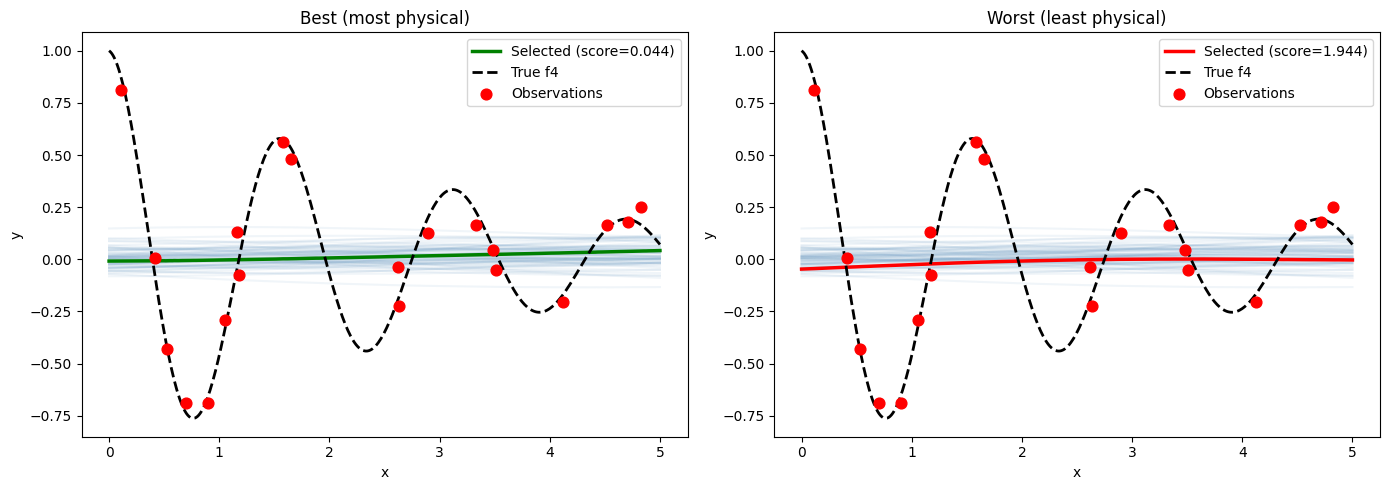

In [34]:
# ── Visualise ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, title, highlight_idx in zip(axes,
                                    ["Best (most physical)", "Worst (least physical)"],
                                    [best_idx, worst_idx]):
    # all candidates (faint)
    for i in range(len(samples_np)):
        ax.plot(x_grid, samples_np[i], color='steelblue', alpha=0.08)

    # highlighted candidate
    color = 'green' if highlight_idx == best_idx else 'red'
    ax.plot(x_grid, samples_np[highlight_idx], color=color, linewidth=2.5,
            label=f'Selected (score={all_scores[highlight_idx]:.3f})')

    # ground truth
    ax.plot(x_grid, f(x_grid), 'k--', linewidth=2, label='True f4')
    ax.scatter(x_exp, y_exp, color='red', s=60, zorder=5, label='Observations')

    ax.set_title(title)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.legend()

# plt.suptitle("Physics-Constrained Candidate Selection — Damped Oscillator", fontsize=13)
plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/physics_selection.png", dpi=150, bbox_inches='tight')
plt.show()




In [35]:
## lets do better kernel as LLM suggest based on seeing ground truth

In [36]:
class DampedOscillatorKernel(gpytorch.kernels.Kernel):
    """
    k(x, x') = exp(-γ |x-x'|) * cos(ω |x-x'|)

    This is the covariance of a stochastic damped harmonic oscillator.
    γ controls decay rate, ω controls oscillation frequency.
    Both are learnable parameters.
    """
    has_lengthscale = False

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # initialise near true values — in practice these would be unknown
        self.register_parameter(
            'raw_gamma', torch.nn.Parameter(torch.tensor(0.5))
        )
        self.register_parameter(
            'raw_omega', torch.nn.Parameter(torch.tensor(2.0))
        )
        # constrain both to be positive
        self.register_constraint('raw_gamma', gpytorch.constraints.Positive())
        self.register_constraint('raw_omega', gpytorch.constraints.Positive())

    @property
    def gamma(self):
        return self.raw_gamma_constraint.transform(self.raw_gamma)

    @property
    def omega(self):
        return self.raw_omega_constraint.transform(self.raw_omega)

    def forward(self, x1, x2, **params):
        # |x - x'|
        diff = torch.cdist(x1, x2, p=1)   # shape (n, m)
        return torch.exp(-self.gamma * diff) * torch.cos(self.omega * diff)

In [37]:
# ── GP model with physics kernel ─────────────────────────────────────────────

class DampedOscillatorGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module  = gpytorch.means.ZeroMean()   # oscillator has zero mean
        self.covar_module = gpytorch.kernels.ScaleKernel(DampedOscillatorKernel())

    def forward(self, x):
        return gpytorch.distributions.MultivariateNormal(
            self.mean_module(x), self.covar_module(x)
        )


def train_gp(model, likelihood, train_x, train_y, lr=0.05, training_iter=300):
    model.train(); likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    losses = []
    for _ in range(training_iter):
        optimizer.zero_grad()
        loss = -mll(model(train_x), train_y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

In [38]:
train_x = torch.tensor(x_exp,  dtype=dtype, device=device).unsqueeze(-1)
train_y = torch.tensor(y_exp,  dtype=dtype, device=device)
test_x  = torch.tensor(x_grid, dtype=dtype, device=device).unsqueeze(-1)

In [39]:
# ── Fit ───────────────────────────────────────────────────────────────────────

likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device=device, dtype=dtype)
model      = DampedOscillatorGP(train_x, train_y, likelihood).to(device=device, dtype=dtype)
losses     = train_gp(model, likelihood, train_x, train_y)

learned_gamma = model.covar_module.base_kernel.gamma.item()
learned_omega = model.covar_module.base_kernel.omega.item()
print(f"Learned γ = {learned_gamma:.3f}  (true: 0.35)")
print(f"Learned ω = {learned_omega:.3f}  (true: 4.00)")

Learned γ = 0.047  (true: 0.35)
Learned ω = 4.072  (true: 4.00)


In [40]:
# ── Posterior & samples ───────────────────────────────────────────────────────

model.eval(); likelihood.eval()

with torch.no_grad():
    posterior  = model(test_x)
    pred_mean  = posterior.mean.cpu().numpy()
    pred_std   = posterior.stddev.cpu().numpy()
    samples_np = posterior.sample(torch.Size([64])).cpu().numpy()

In [41]:
all_scores = np.array([total_score(s)[0] for s in samples_np])
ranked_idx = np.argsort(all_scores)
best_idx   = ranked_idx[0]
worst_idx  = ranked_idx[-1]

print(f"\nBest  score: {all_scores[best_idx]:.4f}")
print(f"Worst score: {all_scores[worst_idx]:.4f}")


Best  score: 0.2017
Worst score: 3.1805


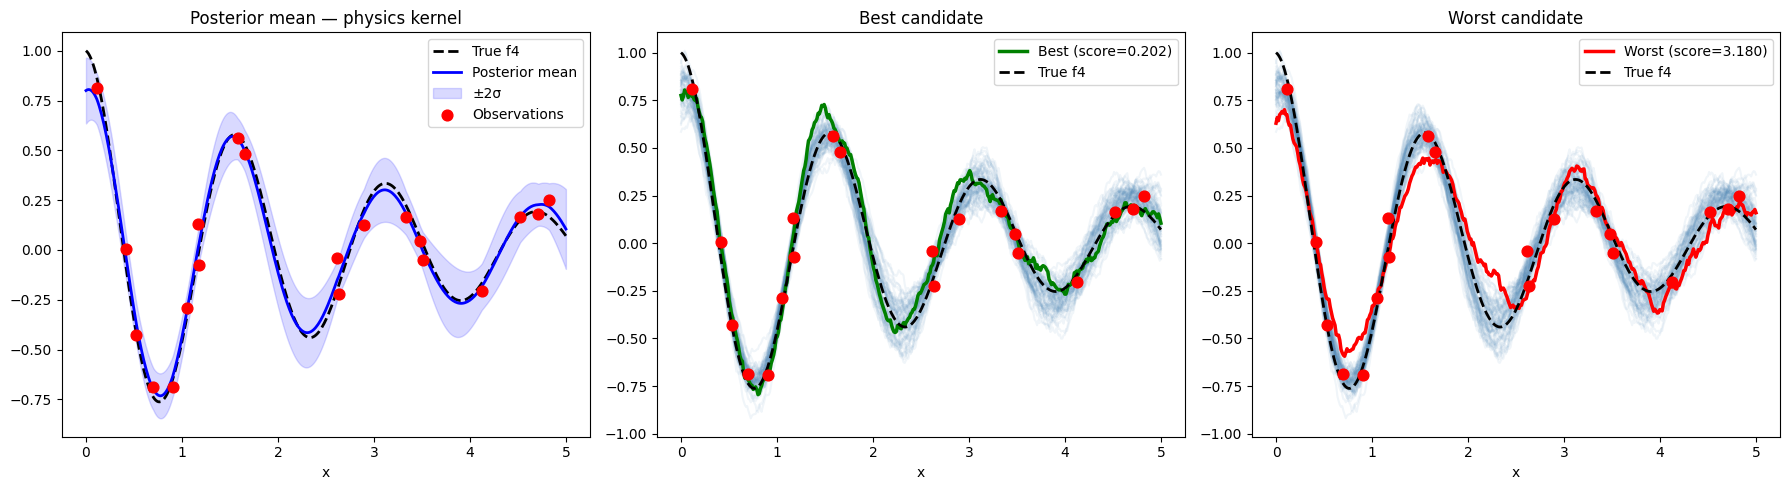

In [42]:
# ── Plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- posterior mean ---
ax = axes[0]
ax.plot(x_grid, f(x_grid), 'k--', lw=2, label='True f4')
ax.plot(x_grid, pred_mean, 'b', lw=2, label='Posterior mean')
ax.fill_between(x_grid, pred_mean - 2*pred_std, pred_mean + 2*pred_std,
                alpha=0.15, color='b', label='±2σ')
ax.scatter(x_exp, y_exp, color='red', s=60, zorder=5, label='Observations')
ax.set_title("Posterior mean — physics kernel"); ax.set_xlabel("x"); ax.legend()

# --- best candidate ---
ax = axes[1]
for s in samples_np:
    ax.plot(x_grid, s, color='steelblue', alpha=0.08)
ax.plot(x_grid, samples_np[best_idx], 'g', lw=2.5,
        label=f'Best (score={all_scores[best_idx]:.3f})')
ax.plot(x_grid, f(x_grid), 'k--', lw=2, label='True f4')
ax.scatter(x_exp, y_exp, color='red', s=60, zorder=5)
ax.set_title("Best candidate"); ax.set_xlabel("x"); ax.legend()

# --- worst candidate ---
ax = axes[2]
for s in samples_np:
    ax.plot(x_grid, s, color='steelblue', alpha=0.08)
ax.plot(x_grid, samples_np[worst_idx], 'r', lw=2.5,
        label=f'Worst (score={all_scores[worst_idx]:.3f})')
ax.plot(x_grid, f(x_grid), 'k--', lw=2, label='True f4')
ax.scatter(x_exp, y_exp, color='red', s=60, zorder=5)
ax.set_title("Worst candidate"); ax.set_xlabel("x"); ax.legend()

# plt.suptitle("Physics-Informed Kernel + Scoring — Damped Oscillator", fontsize=13)
plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/physics_kernel_result.png", dpi=150, bbox_inches='tight')
plt.show()

What worked:

- Physics kernel gave the GP actual oscillatory structure — candidates are now meaningful


In [ ]:
## How does the exsemble one look?? --> probably score greater than threshold ?? - we call it physcis posterior??

In [43]:
# ═════════════════════════════════════════════════════════════════════════════
#  PHYSICS-GATED ENSEMBLE
#  Keep only candidates with score < threshold, then average them.
# ═════════════════════════════════════════════════════════════════════════════

# threshold = median score — keeps roughly top 50%, easy to tune
threshold = np.median(all_scores)
accepted_mask = all_scores < threshold
accepted_idx  = np.where(accepted_mask)[0]

print(f"\nThreshold : {threshold:.4f}")
print(f"Accepted  : {accepted_mask.sum()} / {len(all_scores)} candidates")

accepted_samples = samples_np[accepted_idx]          # shape: (n_accepted, 400)

# simple mean and std across accepted candidates
ensemble_mean = accepted_samples.mean(axis=0)
ensemble_std  = accepted_samples.std(axis=0)



Threshold : 1.0370
Accepted  : 32 / 64 candidates


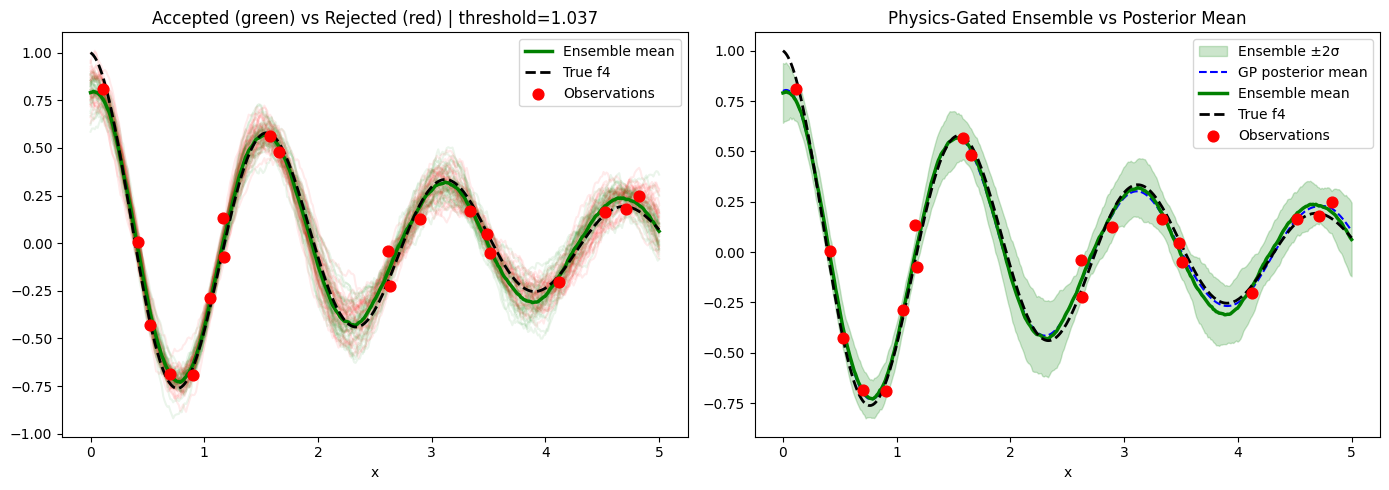

In [45]:
# ── Plot: ensemble vs posterior mean vs truth ─────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, show_all in zip(axes, [True, False]):
    if show_all:
        # show rejected faint red, accepted faint green
        for i in range(len(samples_np)):
            color = 'green' if accepted_mask[i] else 'red'
            ax.plot(x_grid, samples_np[i], color=color, alpha=0.08)
        ax.set_title(f"Accepted (green) vs Rejected (red) | threshold={threshold:.3f}")
    else:
        ax.fill_between(x_grid,
                        ensemble_mean - 2*ensemble_std,
                        ensemble_mean + 2*ensemble_std,
                        alpha=0.2, color='green', label='Ensemble ±2σ')
        ax.set_title("Physics-Gated Ensemble vs Posterior Mean")
        ax.plot(x_grid, pred_mean, 'b--', lw=1.5, label='GP posterior mean')

    ax.plot(x_grid, ensemble_mean, 'green', lw=2.5, label='Ensemble mean')
    ax.plot(x_grid, f(x_grid), 'k--', lw=2, label='True f4')
    ax.scatter(x_exp, y_exp, color='red', s=60, zorder=5, label='Observations')
    ax.set_xlabel("x"); ax.legend()

# plt.suptitle("Physics-Gated Ensemble — Damped Oscillator", fontsize=13)
plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/physics_ensemble_result.png", dpi=150, bbox_inches='tight')
plt.show()

In [46]:
# ── Score improvement ─────────────────────────────────────────────────────────
_, mean_breakdown   = total_score(pred_mean)
_, ens_breakdown    = total_score(ensemble_mean)

print("\nScore comparison — posterior mean vs ensemble mean:")
print(f"  {'criterion':<12}  {'GP mean':>10}  {'Ensemble':>10}")
for k in mean_breakdown:
    print(f"  {k:<12}  {mean_breakdown[k]:>10.4f}  {ens_breakdown[k]:>10.4f}")


Score comparison — posterior mean vs ensemble mean:
  criterion        GP mean    Ensemble
  origin            0.0000      0.0000
  envelope          0.0000      0.0000
  crossing          0.0297      0.0228
  tail              0.1577      0.1564


Findings:

- Ensemble mean tracks the true f4 very closely, even in the tail (x > 3) where data is sparse
- GP posterior mean and ensemble mean are nearly identical — meaning the kernel itself is doing most of the heavy lifting

Note:

- When the kernel already encodes the physics, the scoring becomes redundant for some criteria. The real value of scoring shows up when the kernel is agnostic (like the original RBF case).

Next ideas:
- try mean function?? and remove kernel --> ideally it should lead to same result as the kernel case
- is there a way to select the posterior better?? - case when we dont have ground truth but say 20 samples from it
          - can we fit pysr and get a good guess for kernel?? - fit pysr on the ground truth --> get equation
            - or rather than kernel can do mean function
- Can ask llm directly for a kernel or mean funtion guess??

Q. What is the goal?
- Get a better posterior fit from the physics knowledge
  - can come from better surrogate - from kernel or mean fn change
  - can come from filtering the posterior using thompson sampling and imposing rules

  
Q. What design space we have?
- kernel space
- mean function space
- different interesting surrogate - other than gp? - lets not go there
- also filtering posterior using some logic

Great notes. Let me reflect back what I'm seeing:

**The core tension you've identified:**
- Physics can enter via **kernel** (structural prior) or **mean function** (shape prior) or **posterior filtering** (post-hoc rules)
- When kernel already encodes physics → filtering adds little (as we just saw)
- The interesting regime is **when you don't have ground truth** — realistic case

---

**The three ideas ranked by interest to me:**

1. **PySR → kernel/mean function** — this is the most novel. Fit a symbolic regression on your sparse samples, get an equation, use that equation as the mean function. Essentially automating the physics prior from data itself.

2. **Mean function instead of kernel** — cleaner separation: kernel handles uncertainty structure, mean function handles shape. Easier to interpret physically.

3. **Ask LLM for kernel guess** — actually underrated. You describe the experiment qualitatively, LLM proposes a kernel. That's essentially what happened here — and it worked.

---

**The real question underneath all this:**

> Given only 5-20 noisy points and *some* domain knowledge (but not ground truth), what's the best way to encode that knowledge into the GP?

Which direction pulls you most?

but before that how do you think ensembled sampling might do better than the posterior??

Good question. Here's the thinking:

**The posterior mean is an average over ALL functions** — including unphysical ones. It's optimal in a least-squares sense but not in a physics sense.

**The ensemble (filtered sampling) does something different:**
- It draws *specific* functions, each internally consistent
- Filters to only physically plausible ones
- Averages *those*

So the ensemble mean lives in a **physics-constrained subspace** of the posterior.

---

**When does this actually matter?**

The posterior mean can be "unphysical by averaging" — imagine half the candidates oscillate with phase +φ and half with phase -φ. The posterior mean cancels them out and looks flat. But every individual sample is oscillatory and physical.

This is the **superposition problem** — averaging coherent structures destroys them.

---

**So the ensemble wins specifically when:**
- The posterior has **multimodal structure** (phase ambiguity, frequency ambiguity)
- Data is sparse enough that multiple qualitatively different behaviors are consistent
- Physics rules out one mode entirely

---

**In our f4 case with 20 points** the posterior was already tight enough that this didn't matter much. But with **5 points** — especially if they happened to all fall near zero crossings — you'd see the ensemble pull ahead significantly.

Want to construct that adversarial case deliberately to demonstrate it?

Adversarial y values (should all be ≈ 0): [-0.007 -0.005  0.021  0.114 -0.034]
Accepted: 32 / 128  (threshold=0.044)


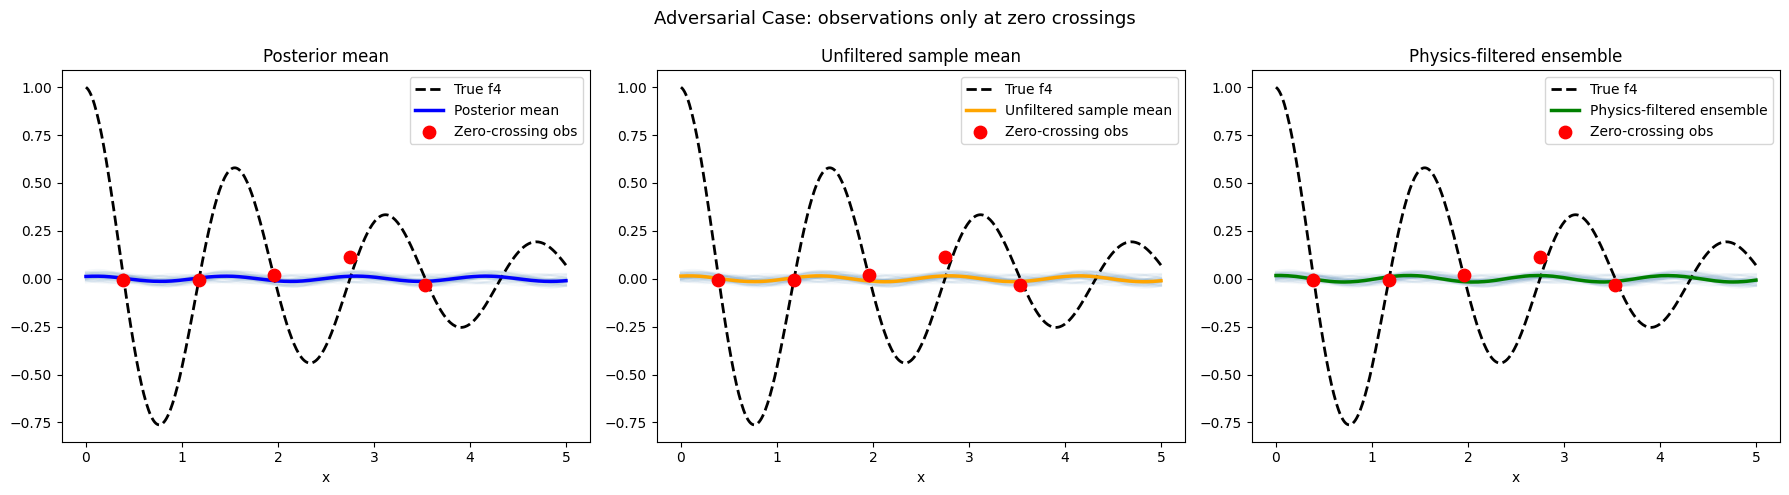

In [50]:
# ── Adversarial points: exactly at zero crossings of f4 ──────────────────────
# cos(4x) = 0  →  x = π/8 + nπ/4  →  x ≈ 0.39, 1.18, 1.96, 2.75, 3.53

x_adversarial = np.array([0.39, 1.18, 1.96, 2.75, 3.53])
y_adversarial = f4(x_adversarial) + np.random.normal(0, 0.05, size=5)

print("Adversarial y values (should all be ≈ 0):", np.round(y_adversarial, 3))

# ── Fit GP (reuse your DampedOscillatorGP) ───────────────────────────────────

train_x = torch.tensor(x_adversarial, dtype=dtype, device=device).unsqueeze(-1)
train_y = torch.tensor(y_adversarial, dtype=dtype, device=device)

likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device=device, dtype=dtype)
model      = DampedOscillatorGP(train_x, train_y, likelihood).to(device=device, dtype=dtype)
train_gp(model, likelihood, train_x, train_y)

model.eval(); likelihood.eval()

with torch.no_grad():
    posterior   = model(test_x)
    pred_mean   = posterior.mean.cpu().numpy()
    pred_std    = posterior.stddev.cpu().numpy()
    samples_np  = posterior.sample(torch.Size([128])).cpu().numpy()

# ── Score & filter ────────────────────────────────────────────────────────────

all_scores  = np.array([total_score(s)[0] for s in samples_np])
threshold   = np.percentile(all_scores, 25)   # stricter — top 25% only
accepted    = samples_np[all_scores < threshold]
rejected    = samples_np[all_scores >= threshold]

ensemble_mean     = accepted.mean(axis=0)
unfiltered_mean   = samples_np.mean(axis=0)   # no filtering — should look flat

print(f"Accepted: {len(accepted)} / {len(samples_np)}  (threshold={threshold:.3f})")

# ── Plot: the key comparison ──────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = ["Posterior mean", "Unfiltered sample mean", "Physics-filtered ensemble"]
lines  = [pred_mean, unfiltered_mean, ensemble_mean]
colors = ['blue', 'orange', 'green']

for ax, title, line, color in zip(axes, titles, lines, colors):
    # faint candidates
    for s in samples_np[:40]:
        ax.plot(x_grid, s, color='steelblue', alpha=0.05)
    ax.plot(x_grid, f4(x_grid), 'k--', lw=2, label='True f4')
    ax.plot(x_grid, line, color=color, lw=2.5, label=title)
    ax.scatter(x_adversarial, y_adversarial, color='red', s=80, zorder=5, label='Zero-crossing obs')
    ax.set_title(title); ax.set_xlabel("x"); ax.legend()

plt.suptitle("Adversarial Case: observations only at zero crossings", fontsize=13)
plt.tight_layout()
plt.show()

sample 0: min=-0.032  max=0.031
sample 1: min=-0.027  max=0.028
sample 2: min=-0.015  max=0.016
sample 3: min=-0.037  max=0.035
sample 4: min=-0.036  max=0.033
sample 5: min=-0.045  max=0.046
sample 6: min=-0.026  max=0.025
sample 7: min=-0.036  max=0.039
sample 8: min=-0.037  max=0.040
sample 9: min=-0.041  max=0.040


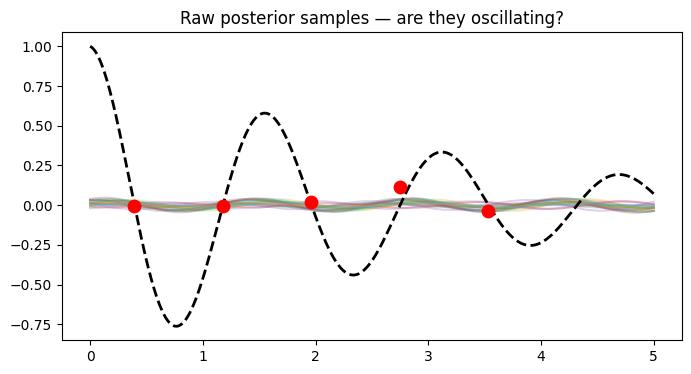

In [51]:
# Are samples actually oscillating or all flat?
for i in range(10):
    print(f"sample {i}: min={samples_np[i].min():.3f}  max={samples_np[i].max():.3f}")



plt.figure(figsize=(8,4))
for i in range(20):
    plt.plot(x_grid, samples_np[i], alpha=0.3)
plt.plot(x_grid, f4(x_grid), 'k--', lw=2)
plt.scatter(x_adversarial, y_adversarial, color='red', s=80, zorder=5)
plt.title("Raw posterior samples — are they oscillating?")
plt.show()

Takeaway:
- Physics filtering only helps when the posterior has meaningful variance. If the posterior is already collapsed (even to the wrong answer), no amount of filtering helps.

Idea: --> dont use physcis kernel
- have 20 points -- 5 seed points
- next 15 points do BO with MU : Instead of adversarial (worst case) or random sampling, you pick points that maximize posterior variance sequentially:
--------> get better model which has spread --> thompson samples
- then filter the posterior based on score

/usr/local/lib/python3.12/dist-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


Accepted: 32 / 128  (threshold=1.019)


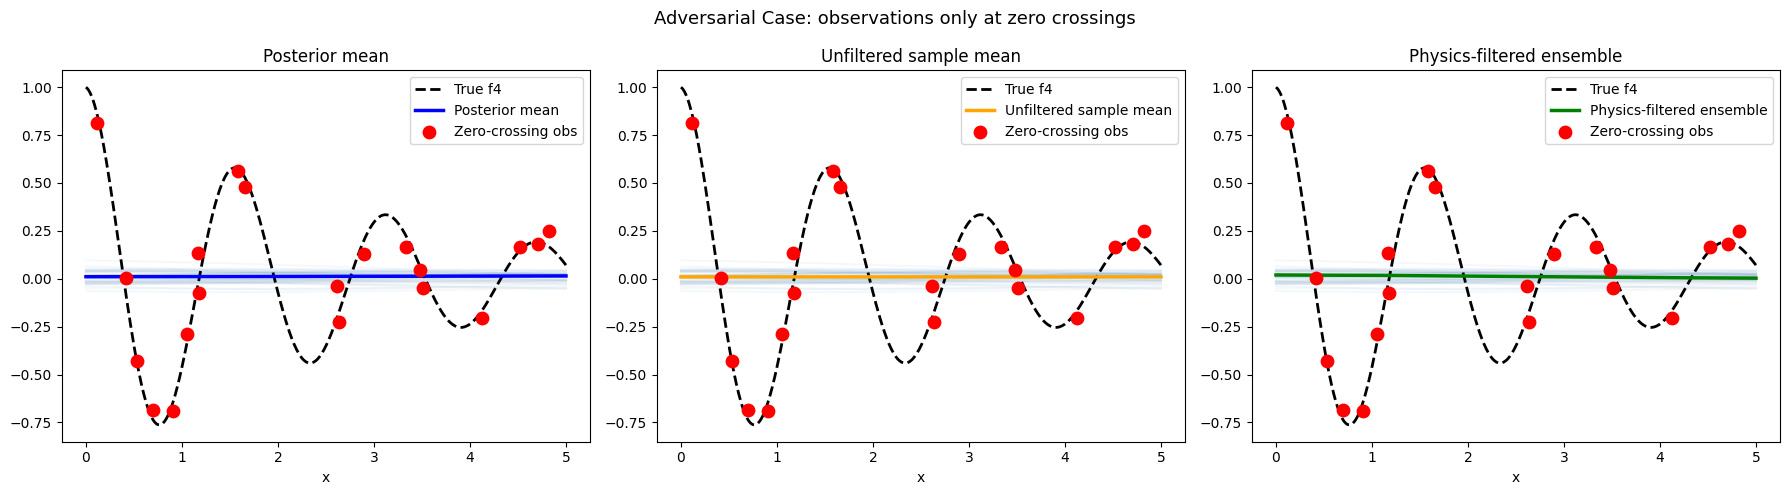

In [55]:
# ── Adversarial points: exactly at zero crossings of f4 ──────────────────────
# cos(4x) = 0  →  x = π/8 + nπ/4  →  x ≈ 0.39, 1.18, 1.96, 2.75, 3.53



# ── Fit GP (reuse your DampedOscillatorGP) ───────────────────────────────────

x_grid = np.linspace(0.0, 5.0, 400)
f = f4

sample_size = 20
np.random.seed(42)
idx = np.sort(np.random.choice(len(x_grid), size=sample_size, replace=False))
x_exp = x_grid[idx]
y_exp = f(x_exp) + np.random.normal(0, 0.1, size=sample_size)

train_x = torch.tensor(x_exp, dtype=dtype, device=device).unsqueeze(-1)
train_y = torch.tensor(y_exp, dtype=dtype, device=device)
test_x  = torch.tensor(x_grid, dtype=dtype, device=device).unsqueeze(-1)

likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device=device, dtype=dtype)
# model      = DampedOscillatorGP(train_x, train_y, likelihood).to(device=device, dtype=dtype)
model      = ExactGPModel(train_x, train_y, likelihood).to(device=device, dtype=dtype)
train_gp(model, likelihood, train_x, train_y)

model.eval(); likelihood.eval()

with torch.no_grad():
    posterior   = model(test_x)
    pred_mean   = posterior.mean.cpu().numpy()
    pred_std    = posterior.stddev.cpu().numpy()
    samples_np  = posterior.sample(torch.Size([128])).cpu().numpy()

# ── Score & filter ────────────────────────────────────────────────────────────

all_scores  = np.array([total_score(s)[0] for s in samples_np])
threshold   = np.percentile(all_scores, 25)   # stricter — top 25% only
accepted    = samples_np[all_scores < threshold]
rejected    = samples_np[all_scores >= threshold]

ensemble_mean     = accepted.mean(axis=0)
unfiltered_mean   = samples_np.mean(axis=0)   # no filtering — should look flat

print(f"Accepted: {len(accepted)} / {len(samples_np)}  (threshold={threshold:.3f})")

# ── Plot: the key comparison ──────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = ["Posterior mean", "Unfiltered sample mean", "Physics-filtered ensemble"]
lines  = [pred_mean, unfiltered_mean, ensemble_mean]
colors = ['blue', 'orange', 'green']

for ax, title, line, color in zip(axes, titles, lines, colors):
    # faint candidates
    for s in samples_np[:40]:
        ax.plot(x_grid, s, color='steelblue', alpha=0.05)
    ax.plot(x_grid, f4(x_grid), 'k--', lw=2, label='True f4')
    ax.plot(x_grid, line, color=color, lw=2.5, label=title)
    ax.scatter(train_x , train_y, color='red', s=80, zorder=5, label='Zero-crossing obs')
    ax.set_title(title); ax.set_xlabel("x"); ax.legend()

plt.suptitle("Adversarial Case: observations only at zero crossings", fontsize=13)
plt.tight_layout()
plt.show()

## TODO: Try BO-MU later


##
Q. What to do to get the best model from pysr?
- get the best datapoints(x, y) from --> can use BO to select those points

Q. What can pysr given function do?
- give mean fn in each bo step ---> llm can help to set up correct mean fn
- give a curve from which llm can help write good kernel
-

Starting Sequential Maximum Variance Sampling...


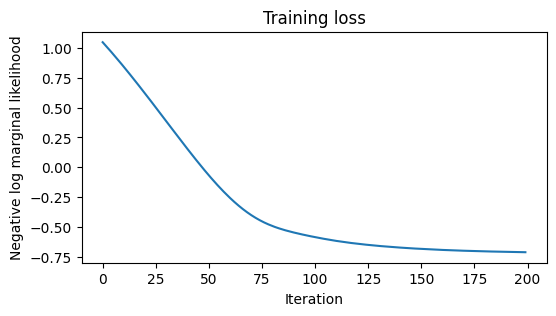

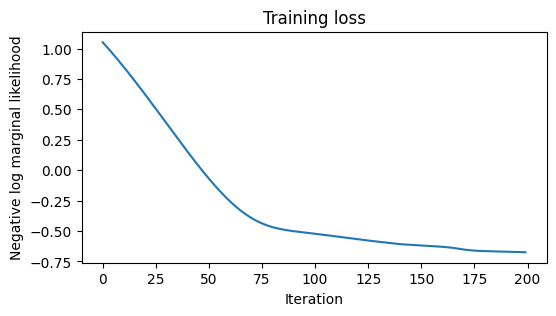

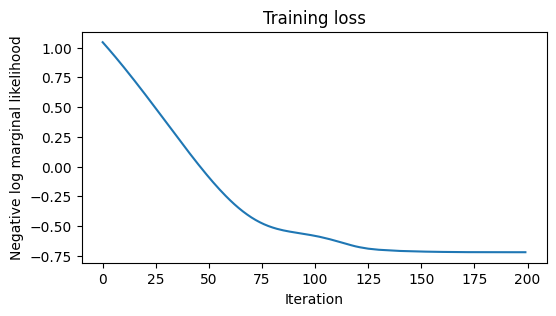

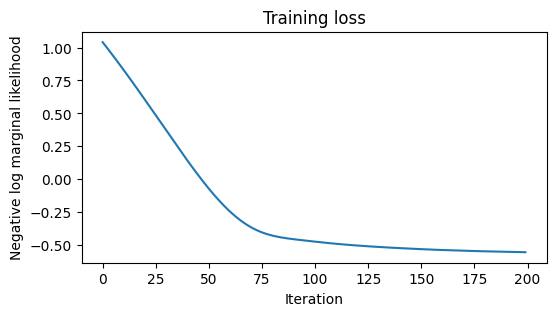

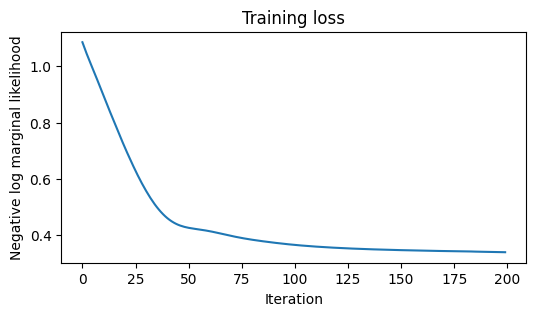

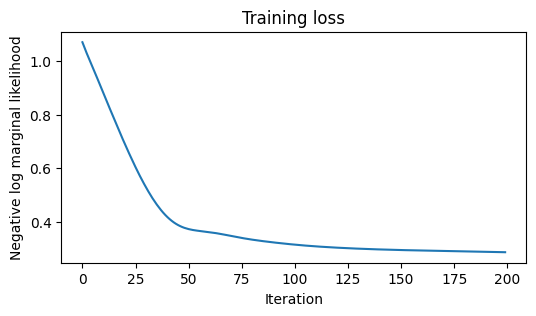

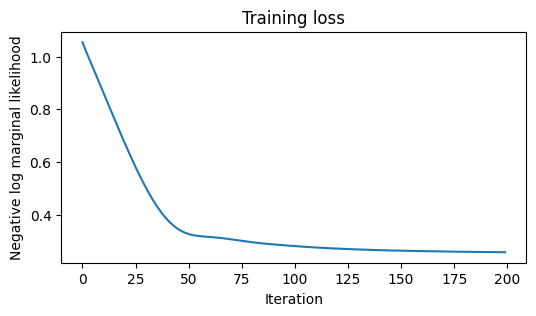

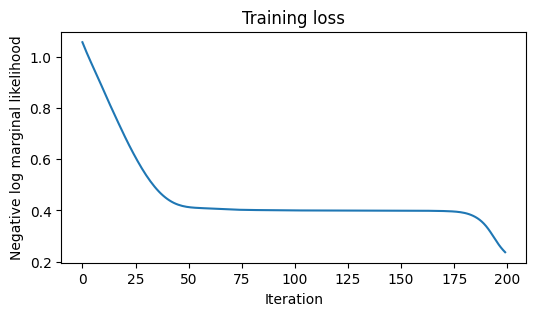

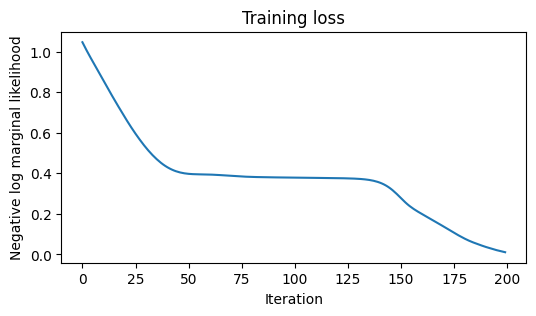

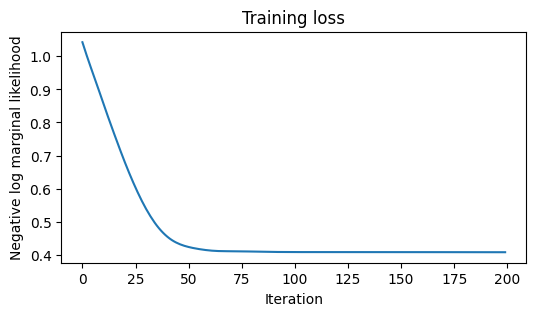

Acquired 10 additional points.


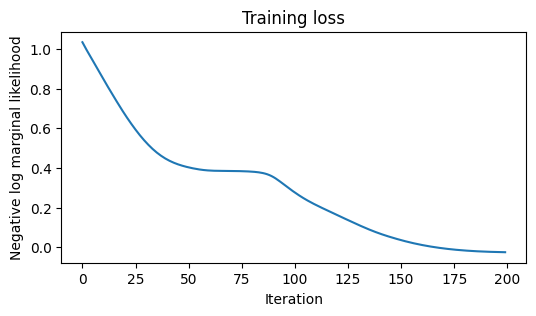

Accepted: 32 / 128  (threshold=0.838)


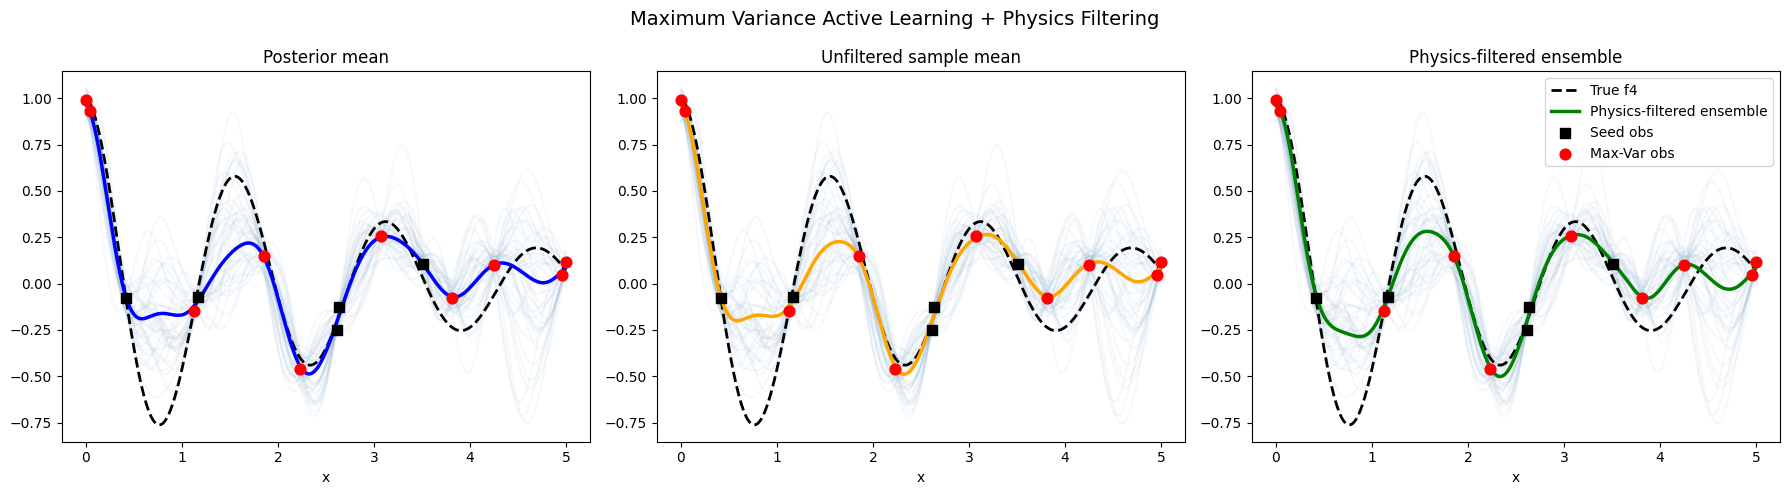

In [88]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import gpytorch

# Assuming device, dtype, ExactGPModel, train_gp, f4, and total_score are defined previously.

# ── 1. Initialization & 5 Seed Points ───────────────────────────────────────
x_grid = np.linspace(0.0, 5.0, 400)
f = f4

n_seed_points = 5
n_bo_steps = 10

np.random.seed(42)
# Pick 5 random starting points
idx = np.random.choice(len(x_grid), size=n_seed_points, replace=False)
x_exp = x_grid[idx].tolist()
y_exp = (f(np.array(x_exp)) + np.random.normal(0, 0.1, size=n_seed_points)).tolist()

# ── 2. Active Learning Loop (Maximum Uncertainty) ───────────────────────────
print("Starting Sequential Maximum Variance Sampling...")

for step in range(n_bo_steps):
    # Prepare current training data
    train_x = torch.tensor(x_exp, dtype=dtype, device=device).unsqueeze(-1)
    train_y = torch.tensor(y_exp, dtype=dtype, device=device)

    # Re-initialize and train the GP on the current dataset
    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device=device, dtype=dtype)
    model = ExactGPModel(train_x, train_y, likelihood).to(device=device, dtype=dtype)
    train_gp(model, likelihood, train_x, train_y)

    model.eval(); likelihood.eval()

    # Find the point on the grid with the highest predictive variance
    with torch.no_grad():
        test_x_tensor = torch.tensor(x_grid, dtype=dtype, device=device).unsqueeze(-1)
        posterior_tmp = model(test_x_tensor)
        variance = posterior_tmp.variance.cpu().numpy()

        # Mask out points we've already sampled so we don't pick them again
        for curr_x in x_exp:
            closest_idx = np.argmin(np.abs(x_grid - curr_x))
            # Create a small exclusion zone to prevent sampling infinitesimally close points
            exclusion_zone = max(1, len(x_grid) // 200)
            variance[max(0, closest_idx - exclusion_zone) : min(len(x_grid), closest_idx + exclusion_zone + 1)] = -1.0

        next_idx = np.argmax(variance)
        next_x = x_grid[next_idx]
        next_y = f(next_x) + np.random.normal(0, 0.1)

        x_exp.append(next_x)
        y_exp.append(next_y)

print(f"Acquired {n_bo_steps} additional points.")

# ── 3. Final Model Fit & Thompson Sampling ──────────────────────────────────
train_x = torch.tensor(x_exp, dtype=dtype, device=device).unsqueeze(-1)
train_y = torch.tensor(y_exp, dtype=dtype, device=device)

likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device=device, dtype=dtype)
model = ExactGPModel(train_x, train_y, likelihood).to(device=device, dtype=dtype)
train_gp(model, likelihood, train_x, train_y)

model.eval(); likelihood.eval()

with torch.no_grad():
    posterior = model(test_x_tensor)
    pred_mean = posterior.mean.cpu().numpy()
    pred_std  = posterior.stddev.cpu().numpy()
    # Draw Thompson samples from the rich, variance-aware posterior
    samples_np = posterior.sample(torch.Size([128])).cpu().numpy()

# ── 4. Score & Filter ───────────────────────────────────────────────────────
all_scores  = np.array([total_score(s)[0] for s in samples_np])
threshold   = np.percentile(all_scores, 25)   # Top 25% only
accepted    = samples_np[all_scores < threshold]
rejected    = samples_np[all_scores >= threshold]

ensemble_mean     = accepted.mean(axis=0)
unfiltered_mean   = samples_np.mean(axis=0)

print(f"Accepted: {len(accepted)} / {len(samples_np)}  (threshold={threshold:.3f})")

# ── 5. Plotting ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = ["Posterior mean", "Unfiltered sample mean", "Physics-filtered ensemble"]
lines  = [pred_mean, unfiltered_mean, ensemble_mean]
colors = ['blue', 'orange', 'green']

# Separate seed points and sequentially acquired points for visualization
seed_x, seed_y = x_exp[:n_seed_points], y_exp[:n_seed_points]
acq_x, acq_y = x_exp[n_seed_points:], y_exp[n_seed_points:]

for ax, title, line, color in zip(axes, titles, lines, colors):
    # Faint candidates
    for s in samples_np[:40]:
        ax.plot(x_grid, s, color='steelblue', alpha=0.05)

    ax.plot(x_grid, f(x_grid), 'k--', lw=2, label='True f4')
    ax.plot(x_grid, line, color=color, lw=2.5, label=title)

    # Plot observations
    ax.scatter(seed_x, seed_y, color='black', marker='s', s=60, zorder=5, label='Seed obs')
    ax.scatter(acq_x, acq_y, color='red', marker='o', s=60, zorder=5, label='Max-Var obs')

    ax.set_title(title)
    ax.set_xlabel("x")
    if ax == axes[-1]: # Only put legend on the last one to save space
        ax.legend()

plt.suptitle("Maximum Variance Active Learning + Physics Filtering", fontsize=14)
plt.tight_layout()
plt.show()